# 🚀 LightGBM vs SARIMA: Demand Forecasting Comparison

This notebook implements and compares two powerful forecasting approaches:
1. **LightGBM**: Champion for granular, multi-feature item-level forecasting.
2. **SARIMA**: Traditional time-series champion for capturing seasonal aggregate trends.

It follows the rigorous pipeline established in previous research notebooks.

In [1]:
%pip install lightgbm pandas numpy matplotlib seaborn scikit-learn holidays statsmodels pmdarima -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, gc, pickle
import holidays
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print("✅ Libraries imported successfully.")


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Libraries imported successfully.


## 1. Helper Functions & Data Loading

In [2]:
def optimize_memory(df, verbose=False):
    for col in df.columns:
        # Only process numeric columns (integers and floats)
        if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_categorical_dtype(df[col]):
            c_min, c_max = df[col].min(), df[col].max()
            if str(df[col].dtype)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max: df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max: df[col] = df[col].astype(np.int16)
                else: df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max: df[col] = df[col].astype(np.float32)
    return df

def create_features(df):
    df['date'] = pd.to_datetime(df['date'])
    df['day'], df['month'], df['year'] = df['date'].dt.day, df['date'].dt.month, df['date'].dt.year
    df['dayofweek'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    ru_holidays = holidays.Russia()
    df['is_holiday'] = df['date'].apply(lambda x: 1 if x in ru_holidays else 0)
    return df

print("📥 Loading datasets...")
try:
    df_sales = pd.read_csv("sales.csv", index_col=0, parse_dates=['date'])
    df_catalog = pd.read_csv("catalog.csv", index_col=0)
    df_sales = df_sales.merge(df_catalog, on='item_id', how='left')
    df_sales = df_sales[(df_sales['quantity'] > 0) & (df_sales['sum_total'] > 0)]
    print("✅ Data loaded.")
except Exception as e:
    print(f"⚠️ Error: {e}")

📥 Loading datasets...


✅ Data loaded.


## 2. Feature Engineering & Preprocessing

In [3]:
df_sales = create_features(df_sales)
df_train = df_sales.groupby(['date', 'item_id', 'store_id']).agg({'quantity': 'sum', 'price_base': 'mean'}).reset_index()
df_train = optimize_memory(df_train)
df_train = create_features(df_train)

print("🛠️ Generating Lags for LightGBM...")
for lag in [7, 14, 28]:
    df_train[f'lag_{lag}'] = df_train.groupby(['item_id', 'store_id'])['quantity'].shift(lag)

df_train.dropna(inplace=True)

le = LabelEncoder()
for col in ['item_id', 'store_id']:
    df_train[col] = le.fit_transform(df_train[col].astype(str))

features = ['day', 'month', 'dayofweek', 'is_weekend', 'is_holiday', 'lag_7', 'lag_14', 'lag_28', 'item_id', 'store_id']
X = df_train[features]
y = np.log1p(df_train['quantity'])

split_idx = int(len(df_train) * 0.85)
X_tr, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_tr, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

🛠️ Generating Lags for LightGBM...


## 3. Training Models
### A. LightGBM (Item-Level)

In [4]:
print("🚀 Training Tuned LightGBM...")
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000, 
    learning_rate=0.03, 
    num_leaves=63, 
    feature_fraction=0.8, 
    bagging_fraction=0.7, 
    bagging_freq=5, 
    n_jobs=-1, 
    verbose=-1
)
lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

lgb_preds_raw = np.expm1(lgb_model.predict(X_val))
lgb_actuals_raw = np.expm1(y_val)

🚀 Training Tuned LightGBM...


Training until validation scores don't improve for 50 rounds


Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 0.228221


### B. SARIMA (Aggregate Daily Trend)
SARIMA is trained on the total daily quantity to capture macroeconomic and seasonal trends.

In [5]:
print("🚀 Training SARIMA on daily aggregates...")
daily_series = df_sales.groupby('date')['quantity'].sum()
train_size = int(len(daily_series) * 0.85)
s_train, s_val = daily_series.iloc[:train_size], daily_series.iloc[train_size:]

# Using optimal parameters found in research
sarima_model = SARIMAX(s_train, order=(1,1,1), seasonal_order=(1,1,1,7), enforce_stationarity=False).fit(disp=False)
sarima_preds = sarima_model.forecast(steps=len(s_val))

🚀 Training SARIMA on daily aggregates...


## 4. Comparison & Visualization


🏆 MODEL COMPARISON (Daily Aggregates):


,RMSE,MAE,MAPE,R2
LightGBM,16609.932213,15716.795054,19.608474,-2.923942
SARIMA,10321.728169,9564.081441,12.291859,-0.515276


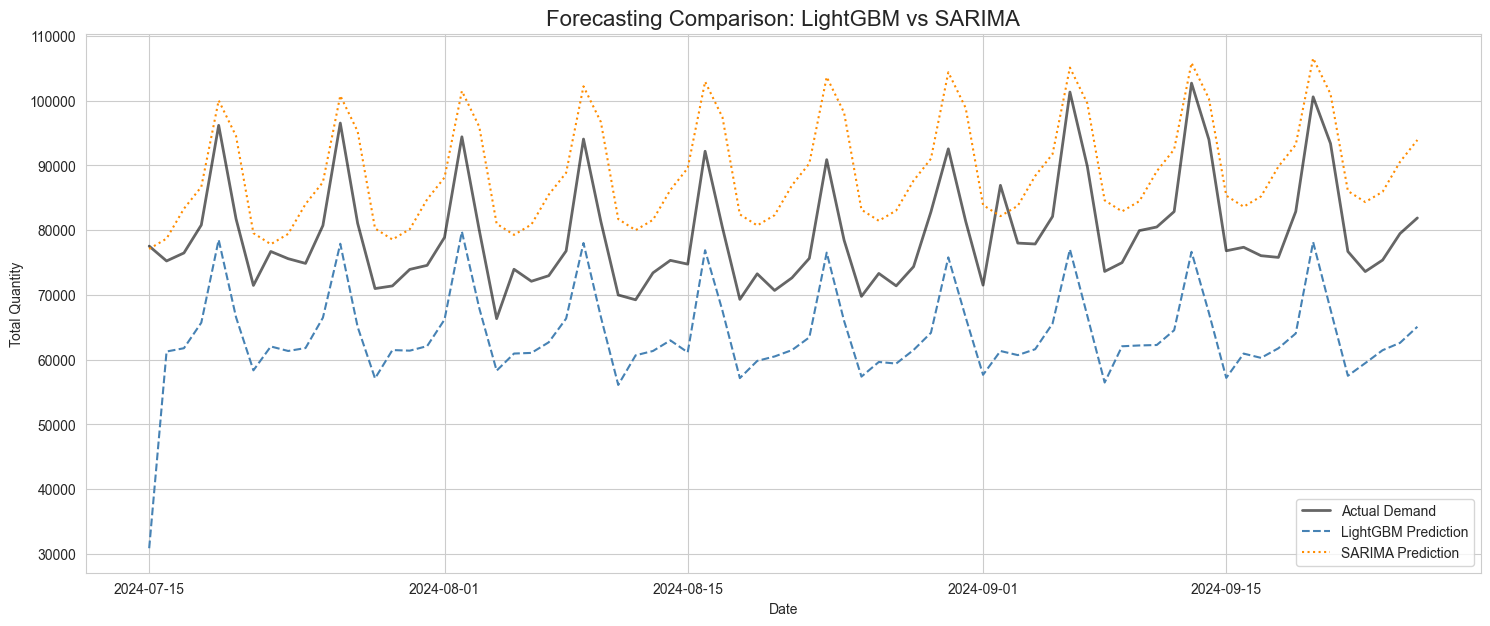

<Figure size 1000x500 with 0 Axes>

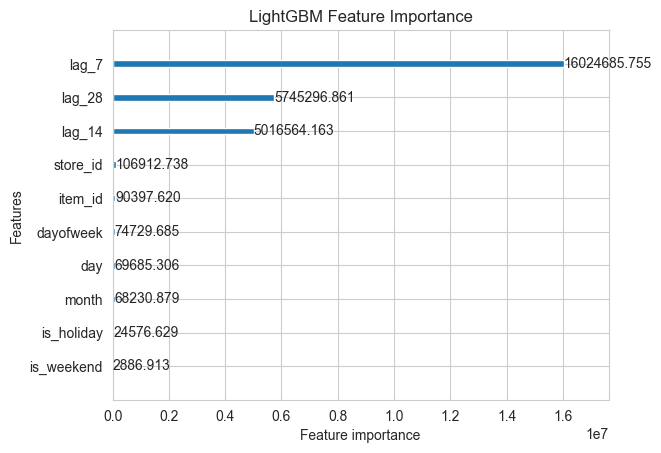

In [6]:
# Aggregate LGBM predictions to daily level for a fair comparison
val_dates = df_train.iloc[split_idx:]['date']
comparison_df = pd.DataFrame({'date': val_dates, 'actual': lgb_actuals_raw, 'lgbm_pred': lgb_preds_raw})
lgbm_daily = comparison_df.groupby('date').sum()

# Align SARIMA and LGBM on the same dates
common_dates = lgbm_daily.index.intersection(s_val.index)
actual_daily = s_val.loc[common_dates]
lgbm_daily = lgbm_daily.loc[common_dates, 'lgbm_pred']
sarima_daily = sarima_preds.loc[common_dates]

def get_metrics(true, pred):
    mask = true > 0
    mape = np.mean(np.abs((true[mask] - pred[mask]) / true[mask])) * 100
    return {
        'RMSE': np.sqrt(mean_squared_error(true, pred)),
        'MAE': mean_absolute_error(true, pred),
        'MAPE': mape,
        'R2': r2_score(true, pred)
    }

metrics_lgbm = get_metrics(actual_daily, lgbm_daily)
metrics_sarima = get_metrics(actual_daily, sarima_daily)

print("\n🏆 MODEL COMPARISON (Daily Aggregates):")
comparison_table = pd.DataFrame({'LightGBM': metrics_lgbm, 'SARIMA': metrics_sarima}).T
display(comparison_table)

# --- Visualizations ---
plt.figure(figsize=(18, 7))
plt.plot(actual_daily.index, actual_daily, label='Actual Demand', color='black', linewidth=2, alpha=0.6)
plt.plot(actual_daily.index, lgbm_daily, label='LightGBM Prediction', color='steelblue', linestyle='--')
plt.plot(actual_daily.index, sarima_daily, label='SARIMA Prediction', color='darkorange', linestyle=':')
plt.title("Forecasting Comparison: LightGBM vs SARIMA", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Total Quantity")
plt.legend()
plt.show()

# Feature Importance for LGBM
plt.figure(figsize=(10, 5))
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='gain', title='LightGBM Feature Importance')
plt.show()